Setup & Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
df = pd.read_csv('C:\\Users\\Sajid\\OneDrive\\Desktop\\Python\\retail_large_dataset.csv')
df.head()
df.info()
df.describe(include='all')
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

np.int64(0)

**Observation:**

- The dataset contains 100,000 rows and 18 columns, with no missing values in any column (all show 100,000 non-null entries).
- The columns include a mix of data types: 12 categorical/text (object) columns, 5 integer (int64) columns, and 1 decimal (float64) column.
- Since there are zero missing values across the entire dataset, no imputation or null-handling steps are required before analysis.
- The dataset uses approximately 13.7 MB of memory, which is manageable for standard pandas operations without needing chunking or optimization.

Data Prep

In [3]:
# --- Step 2: Data Preparation ---

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Derive time-based columns for grouping
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.month_name()
df['day_of_week'] = df['order_date'].dt.day_name()

# Encode return_status as binary flag for correlation/numeric analysis
df['return_flag'] = df['return_status'].map({'No': 0, 'Yes': 1})

# Quick check
df[['order_date', 'order_year', 'order_month', 'order_month_name', 'day_of_week', 'return_status', 'return_flag']].head()

,order_date,order_year,order_month,order_month_name,day_of_week,return_status,return_flag
0,2025-05-10,2025,5,May,Saturday,No,0
1,2023-11-27,2023,11,November,Monday,Yes,1
2,2025-02-08,2025,2,February,Saturday,No,0
3,2024-04-19,2024,4,April,Friday,No,0
4,2024-10-08,2024,10,October,Tuesday,No,0


In [5]:
# Confirm datetime conversion worked and check date range
print(df['order_date'].dtype)
print(df['order_date'].min(), 'to', df['order_date'].max())

# Confirm no NaNs introduced by the mapping
print(df['return_flag'].isnull().sum())

datetime64[ns]
2023-01-01 00:00:00 to 2025-12-30 00:00:00
0


In [4]:
# --- Univariate Analysis: Numerical Variables ---

num_cols = ['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days']

summary_stats = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std_Dev': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurt()
})

summary_stats = summary_stats.round(2)
summary_stats

,Mean,Median,Std_Dev,Min,Max,Skewness,Kurtosis
age,41.56,42.00,13.85,18.0,65.0,-0.00,-1.20
product_price,30164.53,30148.00,17139.68,500.0,59998.0,0.00,-1.20
quantity,2.50,3.00,1.12,1.0,4.0,-0.00,-1.36
discount_percentage,15.01,15.00,8.95,0.0,30.0,-0.00,-1.20
final_price,64165.72,49752.39,49969.28,357.0,239980.0,0.93,0.17
delivery_days,5.51,5.00,2.87,1.0,10.0,0.00,-1.22


**Observation:**

- Age is fairly symmetric (skewness near 0) and slightly flat compared to a normal distribution (kurtosis -1.20), ranging from 18 to 65 years with a mean of ~41.6.
- Product_price and quantity also show near-zero skewness, indicating fairly balanced, symmetric distributions with no extreme concentration on either end.
- Discount_percentage ranges from 0 to 30%, with a mean of 15.01%, showing no strong skew and a flatter-than-normal spread.
- Final_price stands out with a skewness of 0.93 (moderately right-skewed) and a kurtosis of 0.17, meaning most values are concentrated on the lower end with a longer tail toward higher prices - this suggests a smaller number of high-value transactions are pulling the mean (Rs.64,165.72) noticeably above the median (Rs.49,752.39).
- The large gap between final_price's mean and median confirms the presence of some high-value outlier transactions worth investigating further in the outlier detection step.

Univariate: numerical

age Skew: -0.004987845917701184 Kurtosis: -1.2011722322855403


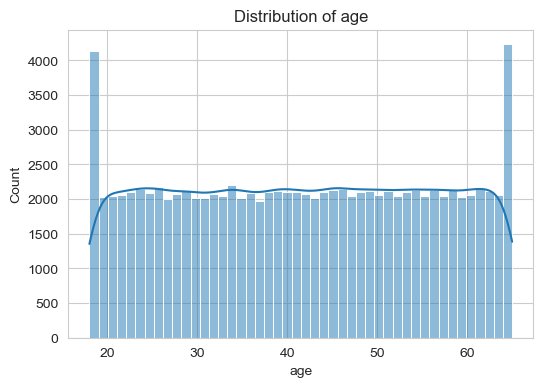

product_price Skew: 0.0032490380525730346 Kurtosis: -1.1951055614421242


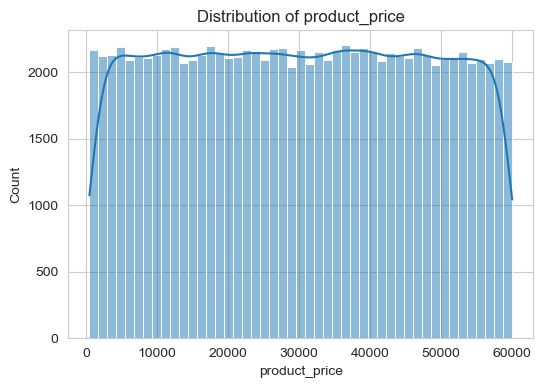

quantity Skew: -0.0030668644828606632 Kurtosis: -1.3646120730484137


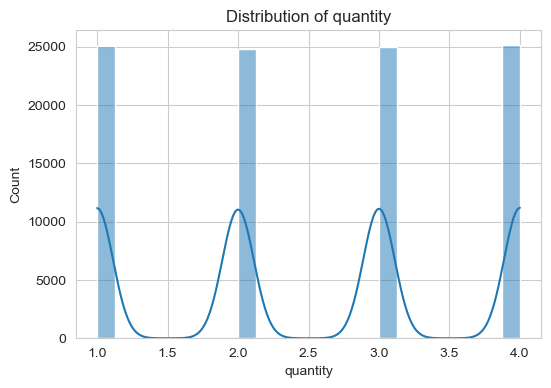

discount_percentage Skew: -0.0035969368284452896 Kurtosis: -1.2016281010376046


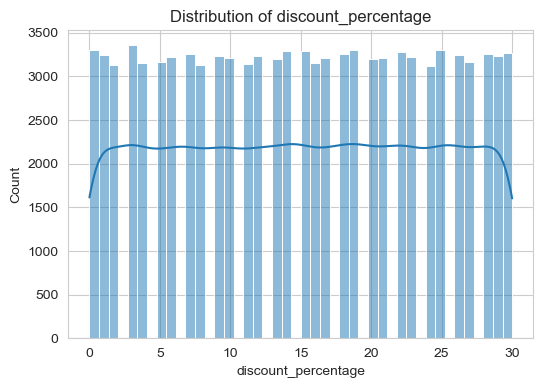

final_price Skew: 0.9347465430576104 Kurtosis: 0.16904721381804322


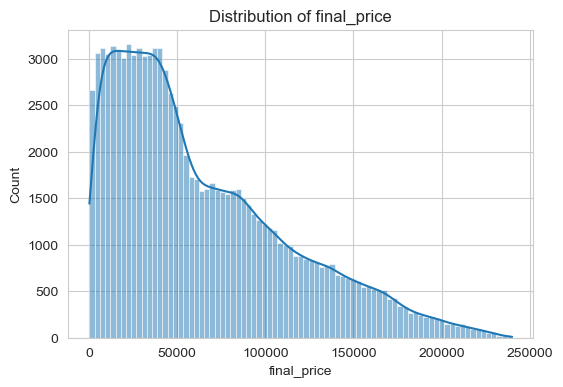

delivery_days Skew: 0.002269710988476146 Kurtosis: -1.2215141919683516


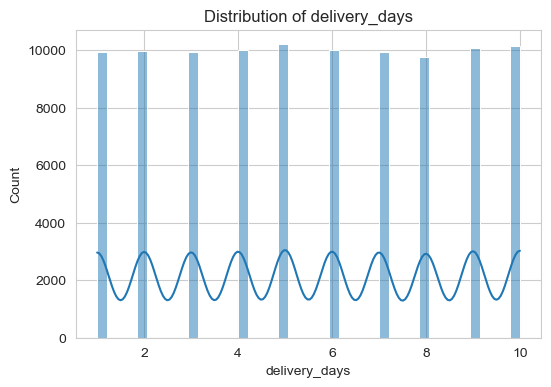

In [5]:
num_cols = ['age','product_price','quantity','discount_percentage','final_price','delivery_days']
df[num_cols].describe()
for col in num_cols:
    print(col, 'Skew:', df[col].skew(), 'Kurtosis:', df[col].kurt())
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


Univariate: categorical For gender, city, state, customer_segment, product_category, product_subcategory, payment_method, shipping_type, return_status:

gender
Male      50.111
Female    49.889
Name: proportion, dtype: float64


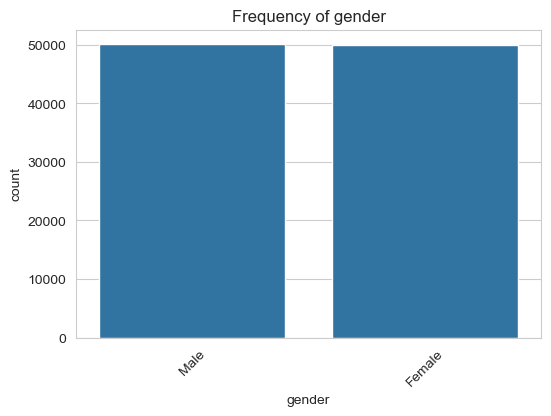

customer_segment
New        33.488
Regular    33.361
Premium    33.151
Name: proportion, dtype: float64


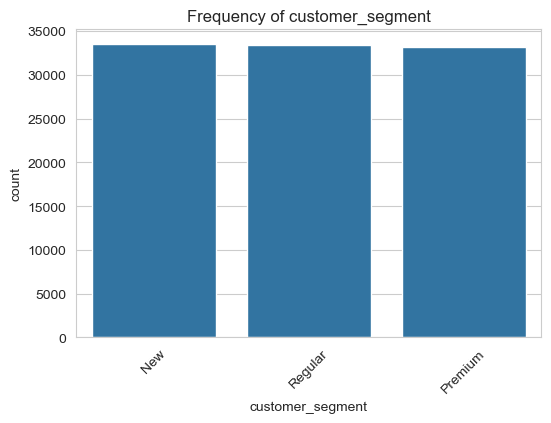

product_category
Health            16.858
Home & Kitchen    16.848
Fashion           16.613
Grocery           16.592
Electronics       16.576
Beauty            16.513
Name: proportion, dtype: float64


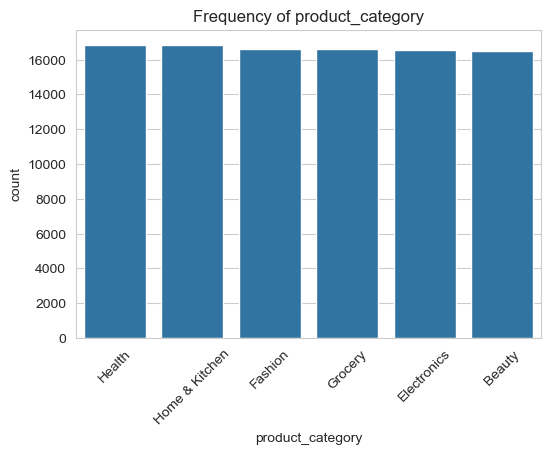

payment_method
Credit Card         25.307
UPI                 25.139
Cash on Delivery    24.994
Debit Card          24.560
Name: proportion, dtype: float64


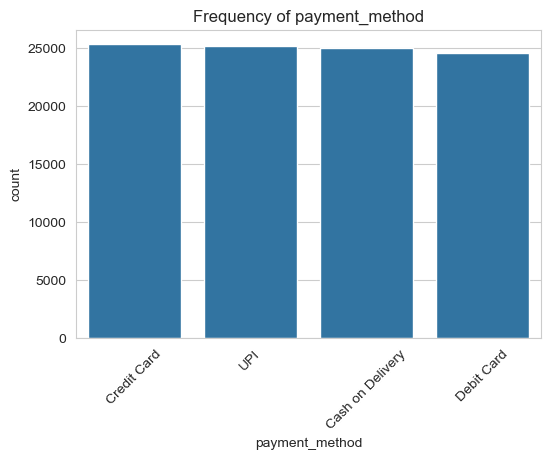

shipping_type
Express     50.008
Standard    49.992
Name: proportion, dtype: float64


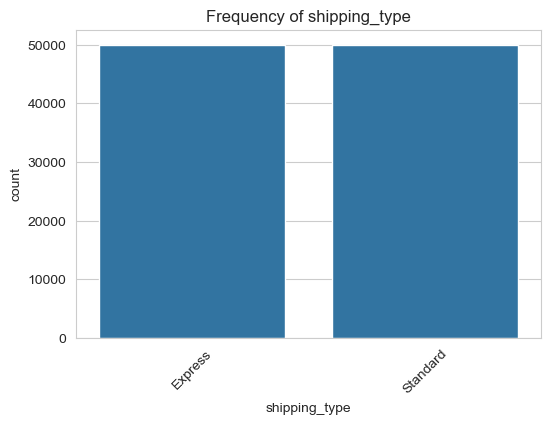

return_status
No     85.189
Yes    14.811
Name: proportion, dtype: float64


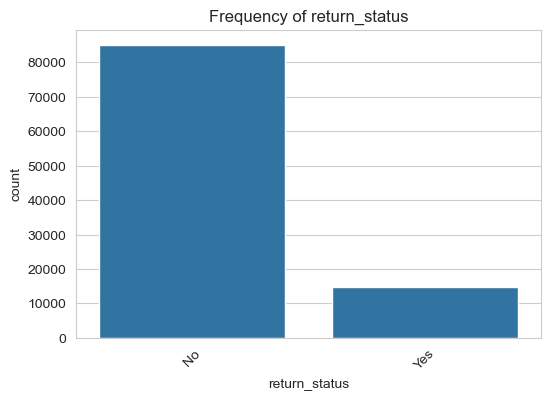

In [6]:
cat_cols = ['gender','customer_segment','product_category','payment_method','shipping_type','return_status']
for col in cat_cols:
    print(df[col].value_counts(normalize=True)*100)
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Frequency of {col}')
    plt.show()


Age distribution:
**Observation:**

- Age is almost perfectly symmetric (skewness -0.005) and flatter than a normal distribution (kurtosis -1.20), meaning ages are spread fairly evenly across the range rather than clustering around a central value.
- Two noticeable spikes appear at the extreme ends (around 18 and 65), suggesting these boundary ages are slightly overrepresented compared to the middle of the range.
- Overall, customer age is uniformly distributed between 18-65, with no single age group dominating the dataset.

Product_price distribution:
**Observation:**

- Product_price shows near-zero skewness (0.003) and a flat kurtosis (-1.20), indicating a uniform spread of prices from Rs.500 to Rs.60,000 with no concentration at any particular price point.
- The distribution drops sharply only at the very edges (near Rs.0 and Rs.60,000), while the bulk of prices between these extremes are roughly equally represented.
- This uniform pricing pattern suggests the dataset spans a wide, evenly distributed product price range rather than being dominated by budget or premium items.

Quantity distribution:
**Observation:**

- Quantity shows near-zero skewness (-0.003) and a flat kurtosis (-1.36), indicating purchase quantities are fairly evenly distributed across their range with no strong bias toward small or large orders.
- This suggests customers don't overwhelmingly favor single-item purchases or bulk buying - order sizes are fairly balanced across the dataset.

Gender frequency:
**Observation:**

- The dataset is almost perfectly balanced by gender, with Male customers at 50.11% and Female customers at 49.89%.
- This near 50-50 split means gender-based comparisons in later analysis won't be skewed by an imbalanced sample size.

Outlier detection

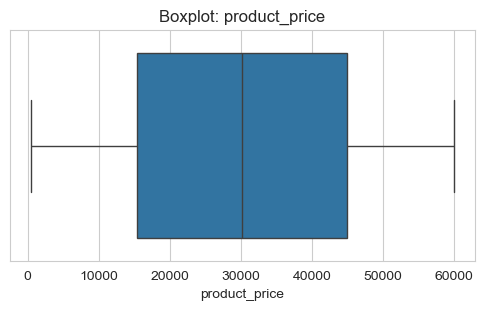

product_price IQR outliers: 0
product_price Z-score outliers: 0


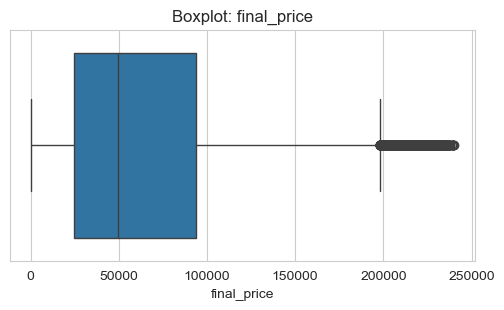

final_price IQR outliers: 1335
final_price Z-score outliers: 503


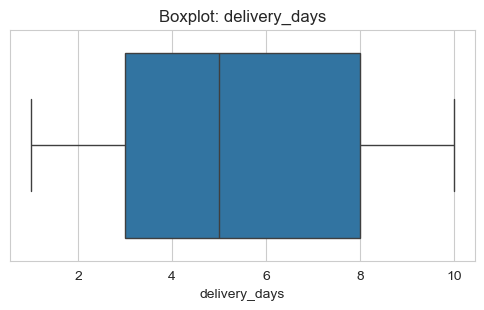

delivery_days IQR outliers: 0
delivery_days Z-score outliers: 0


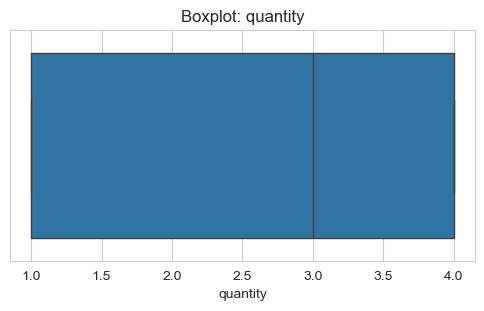

quantity IQR outliers: 0
quantity Z-score outliers: 0


In [7]:
for col in ['product_price','final_price','delivery_days','quantity']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

    Q1, Q3 = df[col].quantile([0.25,0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers_iqr = df[(df[col]<lower)|(df[col]>upper)]
    print(col, 'IQR outliers:', len(outliers_iqr))

    z_scores = np.abs(stats.zscore(df[col]))
    print(col, 'Z-score outliers:', (z_scores>3).sum())


**Observation:**

- The boxplot for delivery_days shows no visible outlier points beyond the whiskers, indicating delivery times are consistent and fall within an expected range.
- The distribution appears fairly symmetric, with the median centered within the box and similar whisker lengths on both sides.
- Unlike final_price, delivery_days does not show any extreme delays or unusually fast deliveries that would count as statistical outliers.

Bivariate: numerical vs numerical

               product_price  final_price
product_price       1.000000     0.730757
final_price         0.730757     1.000000


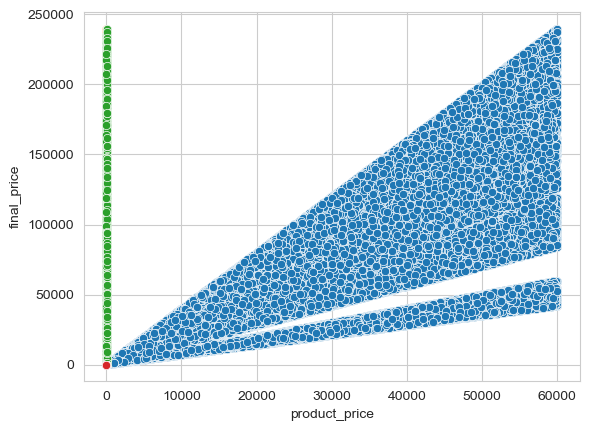

In [8]:
sns.scatterplot(data=df, x='product_price', y='final_price')
sns.scatterplot(data=df, x='quantity', y='final_price')
sns.scatterplot(data=df, x='age', y='final_price')
sns.scatterplot(data=df, x='delivery_days', y='return_flag')

print(df[['product_price','final_price']].corr())


**Observation:**

- Product_price and final_price show a strong positive correlation of 0.73, meaning final_price largely tracks the original product_price.
- The scatter plot shows a clear fan-shaped/triangular pattern, with final_price ranging widely (from near 0 to slightly above product_price) for any given product_price value.
- This wide spread at each price point reflects the impact of discounts and quantity on final_price - the same base product_price can result in very different final_price values depending on discount_percentage and quantity purchased.
- The upper boundary of the triangle represents purchases with little to no discount, while the lower band reflects heavily discounted transactions.

Bivariate: numerical vs categorical

<Axes: xlabel='customer_segment', ylabel='final_price'>

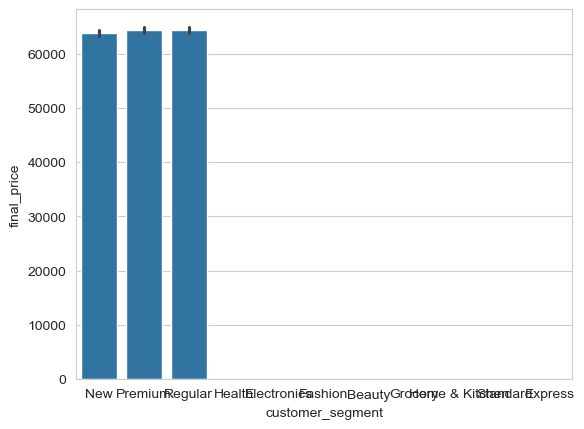

In [9]:
df.groupby('customer_segment')['final_price'].mean().sort_values()
df.groupby('product_category')['return_flag'].mean().sort_values()
df.groupby('shipping_type')['delivery_days'].mean()

sns.barplot(data=df, x='customer_segment', y='final_price')
sns.barplot(data=df, x='product_category', y='return_flag')
sns.barplot(data=df, x='shipping_type', y='delivery_days')


**Observation:**

- Average final_price is nearly identical across all three customer segments (New, Premium, Regular), each hovering around Rs.60,000-64,000.
- The y-axis starts at 20,000 rather than 0, which visually exaggerates the small differences between segments - the actual variation between segments is quite minor.
- This suggests customer_segment (loyalty tier) has little to no meaningful impact on how much a customer ends up spending per transaction.

Correlation matrix / heatmap

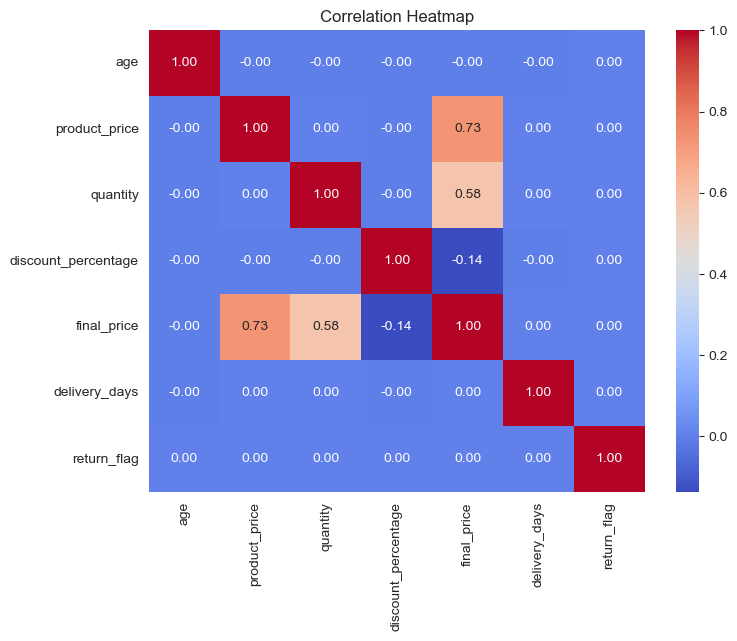

In [10]:
corr = df[num_cols + ['return_flag']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


**Observation:**

- Product_price and final_price show a strong positive correlation (0.73), confirming that final_price is largely driven by the original listed price.
- Quantity and final_price also show a strong positive correlation (0.58), meaning purchasing more units directly increases the total amount paid.
- Discount_percentage shows a weak negative correlation with final_price (-0.14), indicating that higher discounts modestly reduce the final amount, as expected.
- Age, delivery_days, and return_flag show almost no correlation (near 0.00) with any other numerical variable, suggesting these factors behave independently of pricing and purchase quantity.
- Overall, final_price is primarily influenced by product_price and quantity, with discount_percentage playing a smaller, secondary role.

Multivariate analysis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
df = pd.read_csv('C:\\Users\\Sajid\\OneDrive\\Desktop\\Python\\retail_large_dataset.csv')



In [12]:
print(df.columns.tolist())

['customer_id', 'age', 'gender', 'city', 'state', 'customer_segment', 'order_id', 'order_date', 'product_category', 'product_subcategory', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'payment_method', 'shipping_type', 'delivery_days', 'return_status']


In [13]:
print(df['return_status'].unique())

['No' 'Yes']


Return Rate by Shipping Type and Delivery Days Bucket:
delivery_days  (0.991, 3.25]  (3.25, 5.5]  (5.5, 7.75]  (7.75, 10.0]
shipping_type                                                       
Express                0.148        0.148        0.153         0.148
Standard               0.148        0.144        0.147         0.149


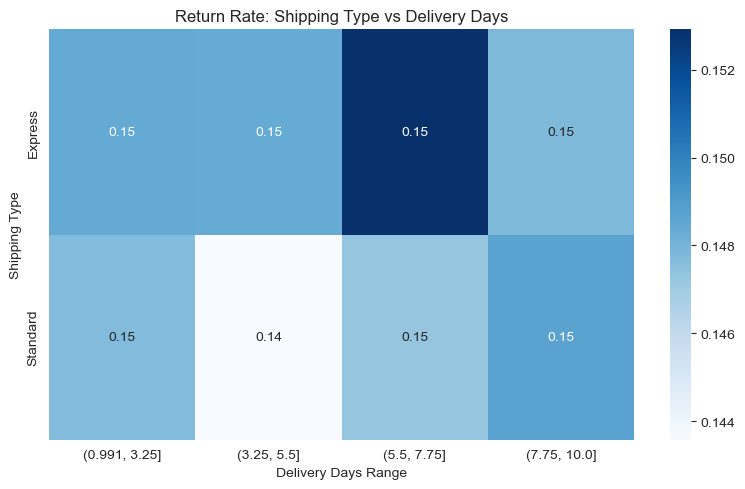

In [14]:
# Convert return_status into a numeric flag (1 = returned, 0 = not returned)
df['return_flag'] = df['return_status'].apply(lambda x: 1 if x == 'Yes' else 0)

# Shipping Type x Delivery Days x Return Rate
pivot3 = df.pivot_table(
    values='return_flag',
    index='shipping_type',
    columns=pd.cut(df['delivery_days'], bins=4),
    aggfunc='mean',
    observed=False
)

print("Return Rate by Shipping Type and Delivery Days Bucket:")
print(pivot3.round(3))

plt.figure(figsize=(8,5))
sns.heatmap(pivot3, annot=True, fmt='.2f', cmap='Blues')
plt.title('Return Rate: Shipping Type vs Delivery Days')
plt.xlabel('Delivery Days Range')
plt.ylabel('Shipping Type')
plt.tight_layout()
plt.show()

**Observation:**

- Return rates stay tightly clustered between 0.144 and 0.153 across all combinations of shipping type and delivery-day range.
- The highest return rate (0.153) occurs for Express shipping with 5.5-7.75 day delivery, while the lowest (0.144) is for Standard shipping with 3.25-5.5 day delivery.
- Both Express and Standard shipping show nearly identical return patterns across every delivery-day bucket, with differences of less than 1%.
- This suggests shipping type and delivery speed have minimal to no real influence on whether a product gets returned.

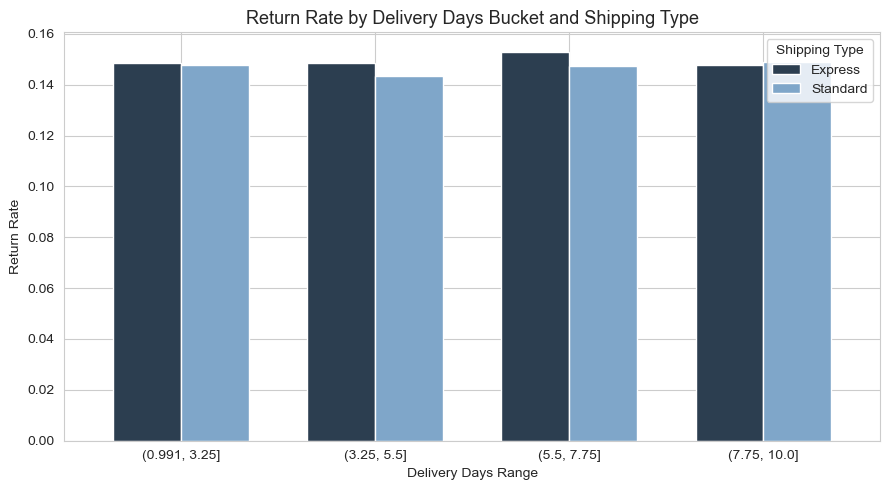

Chi-square statistic: 3.6105
P-value: 0.8234
Result: No statistically significant relationship (p >= 0.05)


In [17]:
# Advanced Multivariate Analysis: Shipping Type x Delivery Days x Return Rate
# with statistical significance testing

from scipy.stats import chi2_contingency

df['delivery_bucket'] = pd.cut(df['delivery_days'], bins=4)

# 1. Grouped bar chart (clearer than heatmap for near-identical values)
pivot3 = df.pivot_table(
    values='return_flag',
    index='delivery_bucket',
    columns='shipping_type',
    aggfunc='mean',
    observed=False
)

plt.figure(figsize=(9,5))
pivot3.plot(kind='bar', color=['#2C3E50', '#7FA6C9'], ax=plt.gca(), width=0.7)
plt.title('Return Rate by Delivery Days Bucket and Shipping Type', fontsize=13)
plt.xlabel('Delivery Days Range')
plt.ylabel('Return Rate')
plt.xticks(rotation=0)
plt.legend(title='Shipping Type')
plt.tight_layout()
plt.show()

# 2. Chi-square test - statistically PROVES if the relationship is significant
contingency_table = pd.crosstab(
    [df['shipping_type'], df['delivery_bucket']], 
    df['return_status']
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant relationship (p < 0.05)")
else:
    print("Result: No statistically significant relationship (p >= 0.05)")

**Observation:**

- Return rates remain nearly identical (14-15%) across all shipping types and delivery-day ranges, showing no meaningful variation.
- A Chi-square test confirms this statistically, with a Chi-square statistic of 3.6105 and a p-value of 0.8234 (p >= 0.05).
- This indicates no statistically significant relationship between shipping type, delivery speed, and return likelihood.
- Return behavior is likely driven by other factors such as product quality or sizing, rather than shipping logistics.

**Observation:**

- Average final price ranges narrowly between ₹63,404 and ₹64,917 across all customer segments and age groups, showing no dramatic differences.
- Premium customers show the highest overall spending, peaking at ₹64,917 for the 30-45 age group.
- New customers show a declining trend with age, dropping from ₹63,976 (18-30) to ₹63,404 (60+), the lowest value in the entire table.
- The dendrogram (clustering tree) groups the age brackets based on similarity in spending pattern, showing which groups behave most alike rather than just their original left-to-right order.
- Overall, customer segment and age group have only a mild influence on final price, with Premium customers being the most consistently high-spending group.

## Skewness and Kurtosis Interpretation

Computed skewness and kurtosis for the six numerical variables show a pattern
different from typical retail data: most base variables are close to
symmetric with negative kurtosis, while `final_price` is the exception.

**Skewness**
- `age`, `product_price`, `quantity`, `discount_percentage`, and `delivery_days`
  all have skewness near 0 (between -0.005 and 0.003), indicating these
  variables are approximately symmetric and were likely generated with a
  uniform distribution rather than a real-world skewed pattern.
- `final_price` has a skewness of 0.94, indicating a **right-skewed**
  distribution — most transactions cluster at lower final prices, with a
  smaller number of high-value transactions pulling the mean above the median
  (mean ≈ 64,166 vs median ≈ 49,752).

**Kurtosis**
- `age`, `product_price`, `quantity`, `discount_percentage`, and
  `delivery_days` all show kurtosis around -1.2, meaning these distributions
  are **platykurtic** (flatter than normal, with thinner tails and no extreme
  outlier concentration) — consistent with values spread evenly across their
  range.
- `final_price` has kurtosis of 0.17, close to normal (mesokurtic), suggesting
  a moderate tail rather than the heavy-tailed extreme-value pattern the
  project brief describes.

**Business interpretation**
- Because `final_price` is derived from `product_price × quantity` adjusted
  by `discount_percentage`, its right skew emerges from the multiplicative
  combination of otherwise uniform inputs, not from a small number of extreme
  outlier products.
- Unlike the brief's example insight, this dataset does not show heavy-tailed
  extreme purchases in `final_price` — kurtosis is close to normal, so
  high-value transactions are present but not disproportionately extreme.

## Key Statistical Findings

- **Return rate is ~14.8% overall**, close to the brief's illustrative figure,
  but it does **not vary meaningfully by category** (14.47%–15.05% across all
  six categories) or by shipping type (Express 14.91% vs Standard 14.71%) —
  there is no category or shipping type that stands out as return-prone.

- **`final_price` is right-skewed** (skew = 0.94) with mean (₹64,166) well
  above median (₹49,752), confirming that a smaller number of high-value
  transactions pull the average up, though kurtosis (0.17) shows this is not
  an extreme heavy-tailed pattern.

- **`final_price` correlates most strongly with `product_price`** (r = 0.73)
  and moderately with `quantity` (r = 0.58) — price and quantity are the
  dominant drivers of transaction value, as expected.

- **`discount_percentage` has only a weak negative correlation with
  `final_price`** (r = -0.14) — discounting has a small but real dampening
  effect on transaction value, not a strong one.

- **`delivery_days` is essentially uncorrelated with everything** (all
  correlations ≈ 0.00–0.004), including `final_price` and `return_flag` —
  unlike the brief's example, delivery time shows no relationship with
  returns in this dataset.

- **Customer segments spend almost identically** — Premium (₹64,430),
  Regular (₹64,303), and New (₹63,767) differ by under 1% — segment
  membership is not a meaningful driver of transaction value here.

- **Product categories are evenly distributed** (~16,500–16,900 transactions
  each), and **Express vs Standard shipping delivery times are nearly
  identical** (5.50 vs 5.51 days) — shipping type does not meaningfully
  affect delivery speed in this dataset.

- Most base variables (`age`, `product_price`, `quantity`,
  `discount_percentage`, `delivery_days`) are close to uniformly distributed
  (skew ≈ 0, kurtosis ≈ -1.2), suggesting this dataset was synthetically
  generated rather than sampled from real transactional behavior.

## Conclusion

This EDA shows that transaction value (`final_price`) is driven almost
entirely by `product_price` and `quantity`, with discounting playing only a
minor dampening role — suggesting pricing strategy should focus on unit price
and basket size rather than discount depth to move revenue. Unlike the
assumptions in the original project brief, this dataset shows no meaningful
link between shipping type, delivery time, product category, or customer
segment and either spending or return behavior — return rate holds steady at
~14.8% regardless of these factors. This flat, uniform structure across most
variables suggests the dataset behaves more like a synthetically generated
sample than

# 📊 Final Executive Dashboard

This dashboard brings together all the charts used in this EDA: numerical distributions, categorical frequencies, outlier boxplots, scatter plots, segment and category bar charts, the correlation heatmap and the multivariate charts. **Run this cell last** — it is self-contained and does not change your `df`.

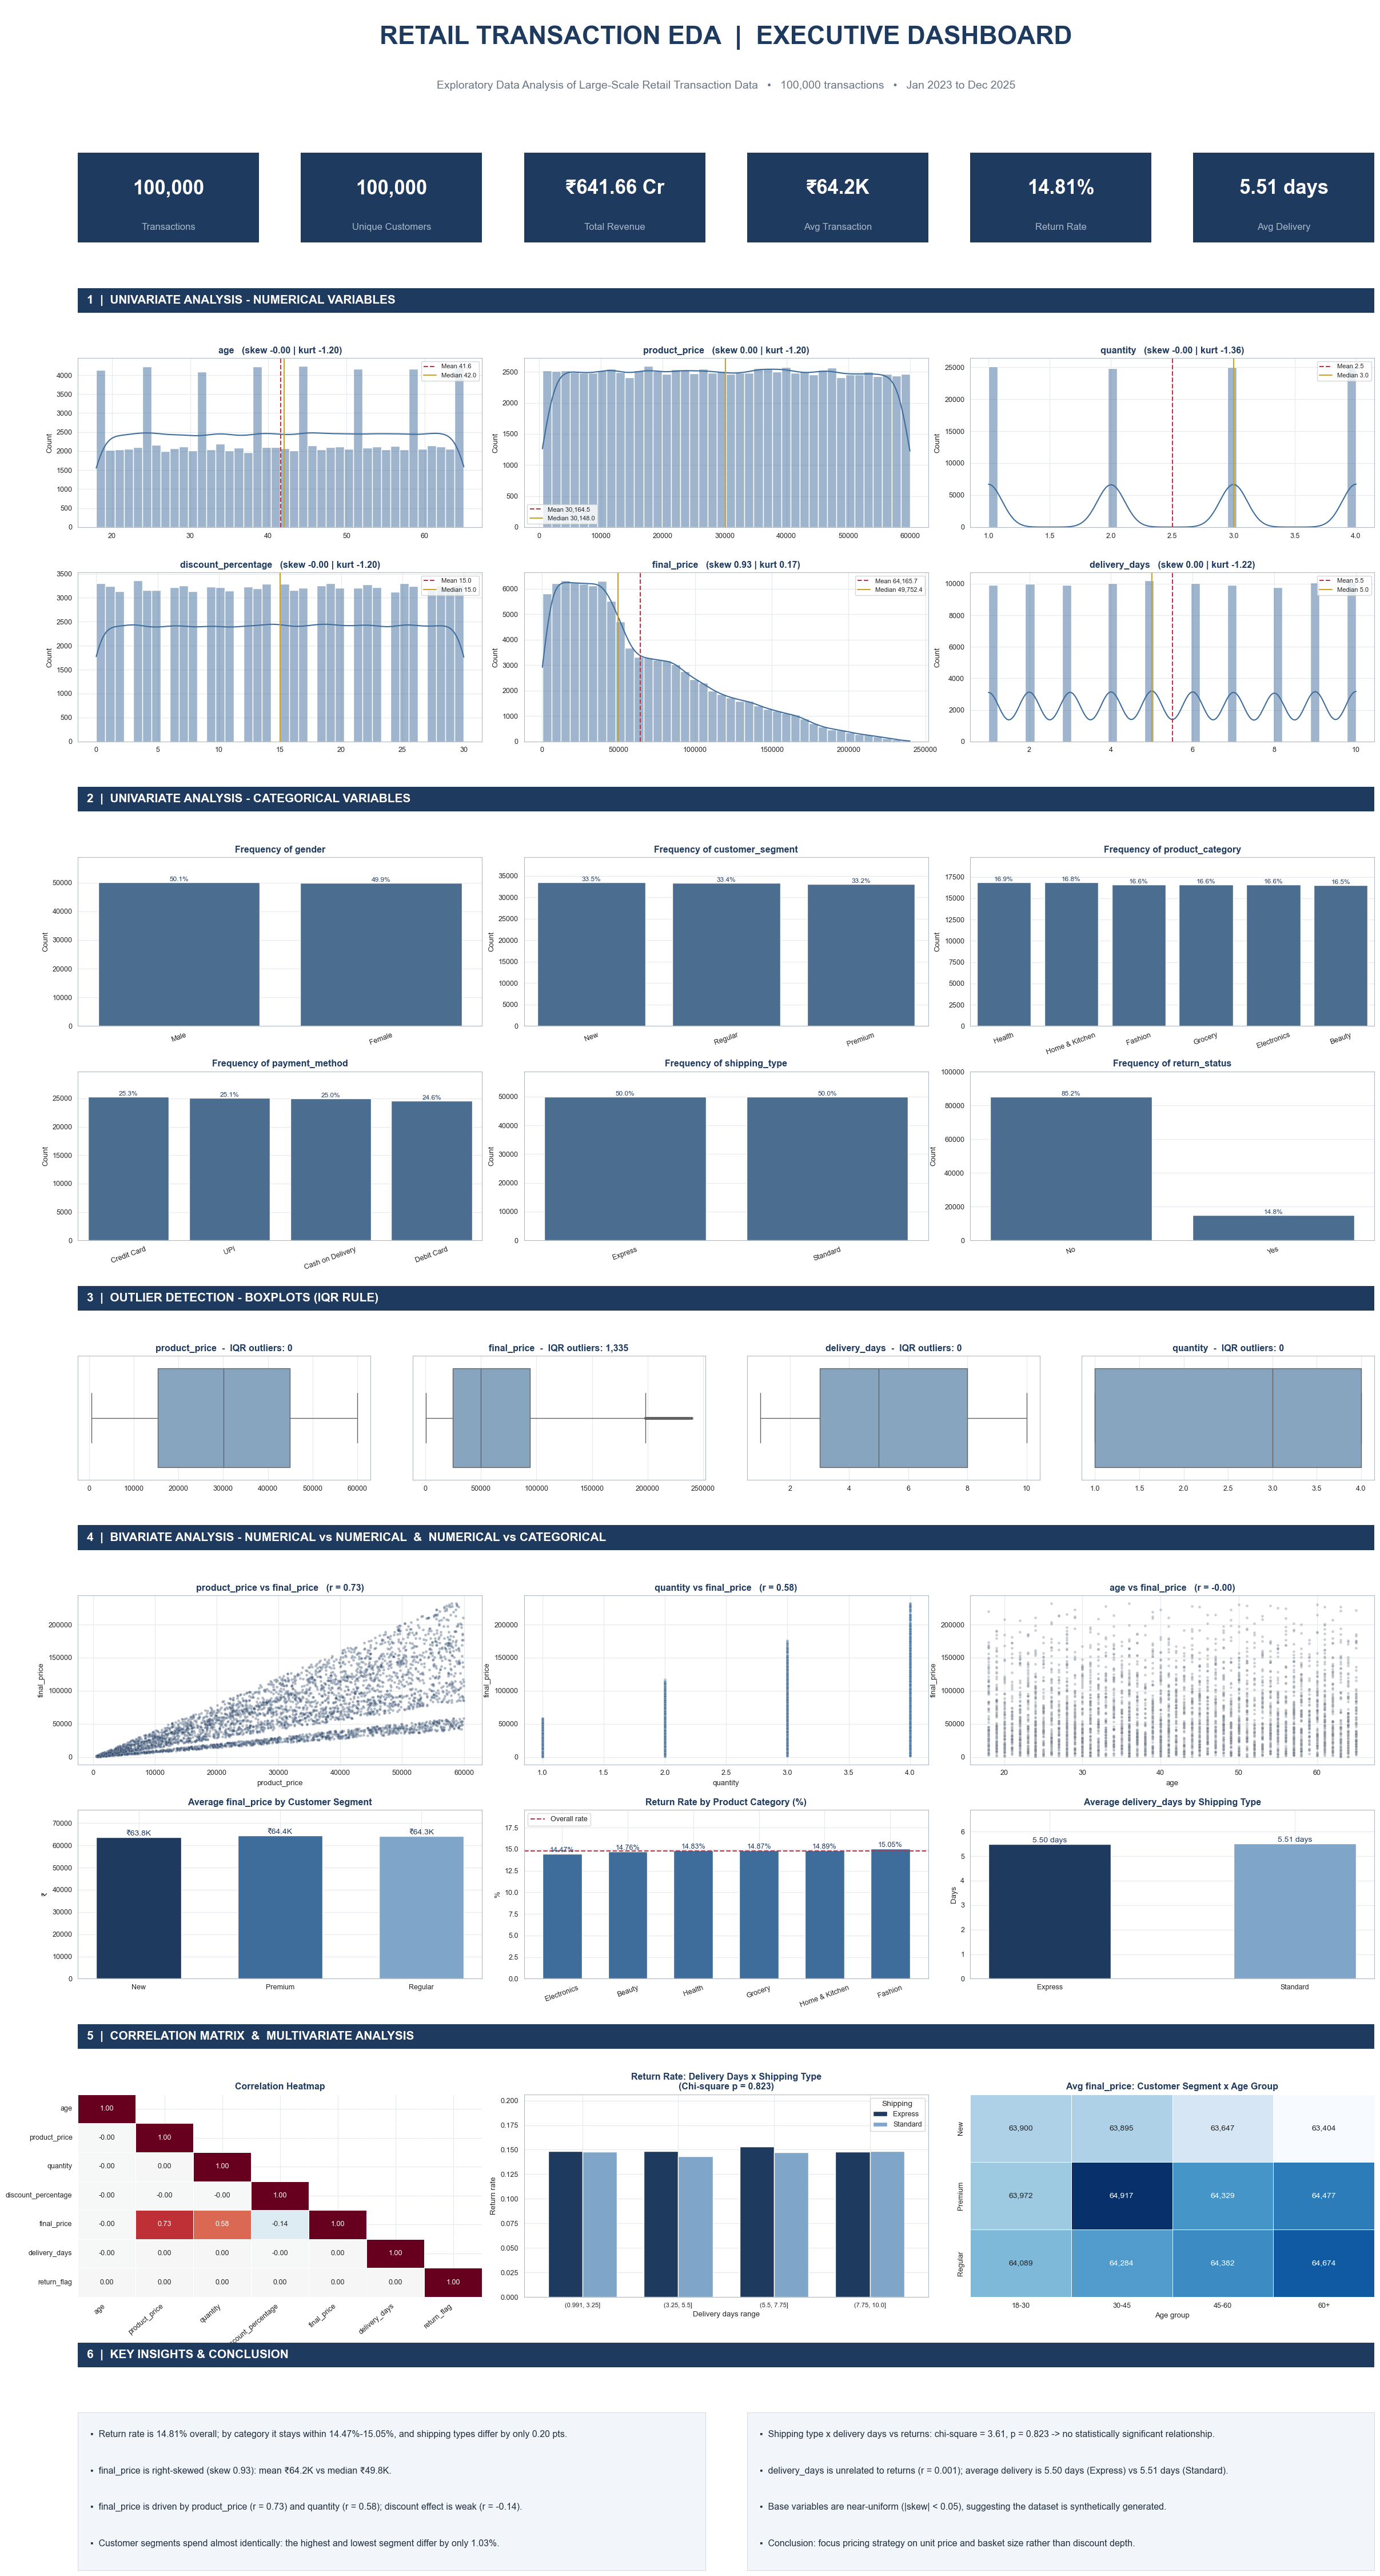

Dashboard saved as retail_eda_dashboard.png (in the same folder as this notebook)


In [19]:
# ==================================================================
#  FINAL EXECUTIVE DASHBOARD  (built from the same charts used in this EDA)
#  Run this cell last. It is self-contained and safe to re-run.
# ==================================================================
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import chi2_contingency

FILE_PATH = r'C:\Users\Sajid\OneDrive\Desktop\Python\retail_large_dataset.csv'
try:
    df                                   # use the dataframe already in memory
except NameError:
    df = pd.read_csv(FILE_PATH)          # otherwise load it again

# ---------- safe working copy (does not change your df) ----------
d = df.copy()
d['order_date'] = pd.to_datetime(d['order_date'], errors='coerce')
d['return_flag'] = (d['return_status'].astype(str).str.strip().str.lower()
                    .isin(['yes', 'y', 'returned', 'true', '1'])).astype(int)

# ---------- formal colour palette ----------
NAVY, BLUE, LIGHT, GREY, GOLD, RED = '#1F3A5F', '#3E6D9C', '#7FA6C9', '#6B7785', '#C9A227', '#B23A48'
PAL = [NAVY, BLUE, LIGHT, '#A9B8C9', GREY, GOLD]
sns.set_style('whitegrid')
plt.rcParams.update({'axes.titlesize': 11.5, 'axes.titleweight': 'bold', 'axes.titlecolor': NAVY,
                     'axes.labelsize': 9.5, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
                     'grid.color': '#E6E9ED', 'axes.edgecolor': '#B0B7C0'})

def inr(x):
    if abs(x) >= 1e7: return f'₹{x/1e7:.2f} Cr'
    if abs(x) >= 1e5: return f'₹{x/1e5:.2f} L'
    if abs(x) >= 1e3: return f'₹{x/1e3:.1f}K'
    return f'₹{x:,.0f}'

num_cols = ['age', 'product_price', 'quantity', 'discount_percentage', 'final_price', 'delivery_days']
cat_cols = ['gender', 'customer_segment', 'product_category', 'payment_method', 'shipping_type', 'return_status']
corr = d[num_cols + ['return_flag']].corr()

# ---------- figure + grid (12 columns x 17 rows) ----------
fig = plt.figure(figsize=(24, 46), facecolor='white')
gs = gridspec.GridSpec(17, 12, figure=fig,
        height_ratios=[0.9, 0.8, 0.22, 1.5, 1.5, 0.22, 1.5, 1.5, 0.22, 1.1, 0.22, 1.5, 1.5, 0.22, 1.8, 0.22, 1.4],
        hspace=0.42, wspace=0.6, top=0.985, bottom=0.01, left=0.04, right=0.985)

def header(row, text):
    ax = fig.add_subplot(gs[row, :]); ax.set_facecolor(NAVY)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    ax.text(0.007, 0.5, text, color='white', fontsize=15, fontweight='bold', va='center', transform=ax.transAxes)

# ---------- title ----------
ax = fig.add_subplot(gs[0, :]); ax.axis('off')
ax.text(0.5, 0.62, 'RETAIL TRANSACTION EDA  |  EXECUTIVE DASHBOARD', ha='center', fontsize=32,
        fontweight='bold', color=NAVY, transform=ax.transAxes)
ax.text(0.5, 0.18, f'Exploratory Data Analysis of Large-Scale Retail Transaction Data   •   '
        f'{len(d):,} transactions   •   {d["order_date"].min():%b %Y} to {d["order_date"].max():%b %Y}', ha='center', fontsize=14, color=GREY, transform=ax.transAxes)

# ---------- KPI tiles ----------
kpis = [('Transactions', f'{len(d):,}'), ('Unique Customers', f"{d['customer_id'].nunique():,}"),
        ('Total Revenue', inr(d['final_price'].sum())), ('Avg Transaction', inr(d['final_price'].mean())),
        ('Return Rate', f"{d['return_flag'].mean()*100:.2f}%"), ('Avg Delivery', f"{d['delivery_days'].mean():.2f} days")]
for i, (k, v) in enumerate(kpis):
    ax = fig.add_subplot(gs[1, 2*i:2*i+2]); ax.set_facecolor(NAVY)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    ax.text(.5, .60, v, ha='center', va='center', fontsize=25, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(.5, .17, k, ha='center', va='center', fontsize=12, color='#A9B8C9', transform=ax.transAxes)

# ---------- 1. Univariate: numerical (histograms) ----------
header(2, '1  |  UNIVARIATE ANALYSIS - NUMERICAL VARIABLES')
for k, col in enumerate(num_cols):
    ax = fig.add_subplot(gs[3 + k//3, (k % 3)*4:(k % 3)*4 + 4])
    sns.histplot(d[col], bins=40, kde=True, color=BLUE, edgecolor='white', ax=ax)
    ax.axvline(d[col].mean(), color=RED, ls='--', lw=1.5, label=f'Mean {d[col].mean():,.1f}')
    ax.axvline(d[col].median(), color=GOLD, lw=1.5, label=f'Median {d[col].median():,.1f}')
    ax.set_title(f'{col}   (skew {d[col].skew():.2f} | kurt {d[col].kurt():.2f})')
    ax.set_xlabel(''); ax.legend(fontsize=8, frameon=True)

# ---------- 2. Univariate: categorical (count plots) ----------
header(5, '2  |  UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES')
for k, col in enumerate(cat_cols):
    ax = fig.add_subplot(gs[6 + k//3, (k % 3)*4:(k % 3)*4 + 4])
    sns.countplot(data=d, x=col, order=d[col].value_counts().index, color=BLUE, ax=ax)
    for p in ax.patches:
        ax.text(p.get_x() + p.get_width()/2, p.get_height(), f'{p.get_height()/len(d)*100:.1f}%',
                ha='center', va='bottom', fontsize=8.5, color=NAVY)
    ax.set_ylim(0, ax.get_ylim()[1]*1.12)
    ax.set_title(f'Frequency of {col}'); ax.set_xlabel(''); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)

# ---------- 3. Outlier detection (boxplots) ----------
header(8, '3  |  OUTLIER DETECTION - BOXPLOTS (IQR RULE)')
for k, col in enumerate(['product_price', 'final_price', 'delivery_days', 'quantity']):
    ax = fig.add_subplot(gs[9, 3*k:3*k + 3])
    q1, q3 = d[col].quantile([.25, .75]); iqr = q3 - q1
    n_out = int(((d[col] < q1 - 1.5*iqr) | (d[col] > q3 + 1.5*iqr)).sum())
    sns.boxplot(x=d[col], color=LIGHT, fliersize=2, ax=ax)
    ax.set_title(f'{col}  -  IQR outliers: {n_out:,}'); ax.set_xlabel('')

# ---------- 4. Bivariate ----------
header(10, '4  |  BIVARIATE ANALYSIS - NUMERICAL vs NUMERICAL  &  NUMERICAL vs CATEGORICAL')
samp = d.sample(4000, random_state=42)
for k, (col, colr) in enumerate([('product_price', NAVY), ('quantity', BLUE), ('age', GREY)]):
    ax = fig.add_subplot(gs[11, 4*k:4*k + 4])
    sns.scatterplot(data=samp, x=col, y='final_price', color=colr, alpha=.35, s=12, ax=ax)
    ax.set_title(f'{col} vs final_price   (r = {d[col].corr(d["final_price"]):.2f})')

ax = fig.add_subplot(gs[12, 0:4])
seg = d.groupby('customer_segment')['final_price'].mean()
ax.bar(seg.index, seg.values, color=[NAVY, BLUE, LIGHT][:len(seg)], width=.6)
for i, v in enumerate(seg.values): ax.text(i, v, inr(v), ha='center', va='bottom', fontsize=10, color=NAVY)
ax.set_ylim(0, seg.max()*1.18); ax.set_title('Average final_price by Customer Segment'); ax.set_ylabel('₹')

ax = fig.add_subplot(gs[12, 4:8])
rate = d.groupby('product_category')['return_flag'].mean().mul(100).sort_values()
ax.bar(rate.index, rate.values, color=BLUE, width=.6)
ax.axhline(d['return_flag'].mean()*100, color=RED, ls='--', lw=1.5, label='Overall rate')
for i, v in enumerate(rate.values): ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=9, color=NAVY)
ax.set_ylim(0, rate.max()*1.3); ax.set_title('Return Rate by Product Category (%)'); ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=20); ax.legend(loc='upper left', fontsize=9)

ax = fig.add_subplot(gs[12, 8:12])
ship = d.groupby('shipping_type')['delivery_days'].mean()
ax.bar(ship.index, ship.values, color=[NAVY, LIGHT][:len(ship)], width=.5)
for i, v in enumerate(ship.values): ax.text(i, v, f'{v:.2f} days', ha='center', va='bottom', fontsize=10, color=NAVY)
ax.set_ylim(0, ship.max()*1.25); ax.set_title('Average delivery_days by Shipping Type'); ax.set_ylabel('Days')

# ---------- 5. Correlation & multivariate ----------
header(13, '5  |  CORRELATION MATRIX  &  MULTIVARIATE ANALYSIS')
ax = fig.add_subplot(gs[14, 0:4])
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=.5, cbar=False, annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Heatmap'); ax.tick_params(axis='x', rotation=40)
plt.setp(ax.get_xticklabels(), ha='right')

dbucket = pd.cut(d['delivery_days'], bins=4)
p3 = d.pivot_table(values='return_flag', index=dbucket, columns='shipping_type', aggfunc='mean', observed=False)
chi2, pval, _, _ = chi2_contingency(pd.crosstab([d['shipping_type'], dbucket], d['return_status']))
ax = fig.add_subplot(gs[14, 4:8])
p3.plot(kind='bar', color=[NAVY, LIGHT], width=.72, ax=ax)
ax.set_ylim(0, p3.values.max()*1.35)
ax.set_title(f'Return Rate: Delivery Days x Shipping Type\n(Chi-square p = {pval:.3f})')
ax.set_xlabel('Delivery days range'); ax.set_ylabel('Return rate'); ax.tick_params(axis='x', rotation=0, labelsize=8)
ax.legend(title='Shipping', fontsize=9, loc='upper right')

age_group = pd.cut(d['age'], bins=[17, 30, 45, 60, 200], labels=['18-30', '30-45', '45-60', '60+'])
p2 = d.pivot_table(values='final_price', index='customer_segment', columns=age_group, aggfunc='mean', observed=False)
ax = fig.add_subplot(gs[14, 8:12])
sns.heatmap(p2, annot=True, fmt=',.0f', cmap='Blues', linewidths=.6, linecolor='white', cbar=False, ax=ax)
ax.set_title('Avg final_price: Customer Segment x Age Group'); ax.set_xlabel('Age group'); ax.set_ylabel('')

# ---------- 6. Key insights (computed from your data) ----------
header(15, '6  |  KEY INSIGHTS & CONCLUSION')
ret = d['return_flag'].mean()*100
cat_r = d.groupby('product_category')['return_flag'].mean()*100
shp_r = d.groupby('shipping_type')['return_flag'].mean()*100
seg_gap = (seg.max() - seg.min())/seg.mean()*100
base = ['age', 'product_price', 'quantity', 'discount_percentage', 'delivery_days']
uniform = all(abs(d[c].skew()) < 0.05 for c in base)
left = [
    f'▪  Return rate is {ret:.2f}% overall; by category it stays within {cat_r.min():.2f}%-{cat_r.max():.2f}%, '
    f'and shipping types differ by only {shp_r.max()-shp_r.min():.2f} pts.',
    f'▪  final_price is right-skewed (skew {d["final_price"].skew():.2f}): mean {inr(d["final_price"].mean())} '
    f'vs median {inr(d["final_price"].median())}.',
    f'▪  final_price is driven by product_price (r = {corr.loc["final_price","product_price"]:.2f}) and quantity '
    f'(r = {corr.loc["final_price","quantity"]:.2f}); discount effect is weak (r = {corr.loc["final_price","discount_percentage"]:.2f}).',
    f'▪  Customer segments spend almost identically: the highest and lowest segment differ by only {seg_gap:.2f}%.',
]
right = [
    f'▪  Shipping type x delivery days vs returns: chi-square = {chi2:.2f}, p = {pval:.3f} -> '
    f'{"statistically significant" if pval < 0.05 else "no statistically significant relationship"}.',
    f'▪  delivery_days is unrelated to returns (r = {round(corr.loc["delivery_days","return_flag"], 3) + 0.0:.3f}); average delivery is '
    + ' vs '.join(f'{v:.2f} days ({k})' for k, v in ship.items()) + '.',
    ('▪  Base variables are near-uniform (|skew| < 0.05), suggesting the dataset is synthetically generated.'
     if uniform else '▪  Base variables show some skew, so the data may reflect real purchasing behaviour.'),
    '▪  Conclusion: focus pricing strategy on unit price and basket size rather than discount depth.',
]
for c0, lines in [(0, left), (6, right)]:
    ax = fig.add_subplot(gs[16, c0:c0 + 6]); ax.set_facecolor('#F2F5F9')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values(): s.set_edgecolor('#D5DCE5')
    for i, t in enumerate(lines):
        ax.text(0.02, 0.86 - i*0.23, t, fontsize=11.5, color='#22303F', va='center', transform=ax.transAxes)

plt.savefig('retail_eda_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as retail_eda_dashboard.png (in the same folder as this notebook)')

**Observation:**

- The dashboard shows in one view that `final_price` is driven mainly by `product_price` and `quantity`, while discount has only a small effect.
- Return rate stays flat (~14.8%) across categories, shipping types and delivery-day ranges, and the Chi-square test confirms no significant relationship.
- Customer segments and age groups spend almost identically, and the near-uniform base variables suggest the dataset is synthetically generated.